In [1]:
import cv2
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from dataclasses import dataclass
import os
import matplotlib
from scipy.signal import find_peaks


# 1 Preprocessing

In [2]:
@dataclass
class Component:
    """Class to store connected component information"""
    bbox: Tuple[int, int, int, int]  # x, y, w, h
    centroid: Tuple[float, float]
    area: int
    contour_length: int


In [3]:
def kfill(binary_image, k=5, max_iterations=10):
    """
    Implement the kFill filter for noise reduction in binary document images.
    This is the Will filter mentioned in the paper.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        k (int): Window size parameter (must be odd).
        max_iterations (int): Maximum number of iterations to perform.
        
    Returns:
        numpy.ndarray: Filtered binary image.
    """
    # Ensure k is odd
    if k % 2 == 0:
        k = k + 1
    
    # Create a copy of the image
    filtered_image = binary_image.copy()
    
    iteration = 0
    changes_made = True
    
    # Continue until no changes or max iterations reached
    while changes_made and iteration < max_iterations:
        changes_made = False
        iteration += 1
        
        # Perform ON-fill and OFF-fill sub-iterations
        for fill_value in [1, 0]:  # 1 for ON-fill, 0 for OFF-fill
            height, width = filtered_image.shape
            
            # Create a copy to store changes for this sub-iteration
            temp_image = filtered_image.copy()
            
            # Process each pixel
            for y in range(k//2, height - k//2):
                for x in range(k//2, width - k//2):
                    # Extract window
                    window = filtered_image[y - k//2 : y + k//2 + 1, x - k//2 : x + k//2 + 1]
                    
                    # Define core and neighborhood
                    core = window[1:-1, 1:-1]
                    
                    # Only proceed if all core values are opposite of fill_value
                    if fill_value == 1 and np.any(core == 1):
                        continue
                    if fill_value == 0 and np.any(core == 0):
                        continue
                    
                    # Extract neighborhood (perimeter of window)
                    neighborhood = np.concatenate([
                        window[0, :],                # Top row
                        window[-1, :],               # Bottom row
                        window[1:-1, 0],             # Left column (without corners)
                        window[1:-1, -1]             # Right column (without corners)
                    ])
                    
                    # Calculate n (number of ON or OFF pixels in neighborhood)
                    if fill_value == 1:
                        n = np.sum(neighborhood == 1)  # Count ON pixels
                    else:
                        n = np.sum(neighborhood == 0)  # Count OFF pixels
                    
                    # Calculate c (number of connected groups in neighborhood)
                    # We need to analyze the neighborhood as a circular list
                    expanded_neighborhood = np.concatenate([neighborhood, neighborhood[0:1]])
                    c = 0
                    for i in range(len(neighborhood)):
                        if expanded_neighborhood[i] != expanded_neighborhood[i+1]:
                            c += 1
                    c = c // 2  # Each transition is counted twice (ON->OFF and OFF->ON)
                    
                    # Calculate r (number of corner pixels that are ON or OFF)
                    corners = [window[0, 0], window[0, -1], window[-1, 0], window[-1, -1]]
                    if fill_value == 1:
                        r = sum(1 for corner in corners if corner == 1)
                    else:
                        r = sum(1 for corner in corners if corner == 0)
                    
                    # Apply kFill condition: (c = 1) AND [(n > 3k - 4) OR (n = 3k - 4) AND r = 2]
                    if (c == 1) and ((n > 3*k - 4) or ((n == 3*k - 4) and (r == 2))):
                        # Fill the core
                        temp_image[y - k//2 + 1 : y + k//2, x - k//2 + 1 : x + k//2] = fill_value
                        changes_made = True
            
            # Update filtered_image with the results of this sub-iteration
            filtered_image = temp_image.copy()
    
    return filtered_image


In [4]:
image_path = "test1.png"
max_iterations = 10
kfill_threshold = 5

In [5]:
def kfill(binary_image, k=5, max_iterations=10):
    """
    Implement the kFill filter for noise reduction in binary document images.
    This is the Will filter mentioned in the paper.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        k (int): Window size parameter (must be odd).
        max_iterations (int): Maximum number of iterations to perform.
        
    Returns:
        numpy.ndarray: Filtered binary image.
    """
    # Ensure k is odd
    if k % 2 == 0:
        k = k + 1
    
    # Create a copy of the image
    filtered_image = binary_image.copy()
    
    iteration = 0
    changes_made = True
    
    # Continue until no changes or max iterations reached
    while changes_made and iteration < max_iterations:
        changes_made = False
        iteration += 1
        
        # Perform ON-fill and OFF-fill sub-iterations
        for fill_value in [1, 0]:  # 1 for ON-fill, 0 for OFF-fill
            height, width = filtered_image.shape
            
            # Create a copy to store changes for this sub-iteration
            temp_image = filtered_image.copy()
            
            # Process each pixel
            for y in range(k//2, height - k//2):
                for x in range(k//2, width - k//2):
                    # Extract window
                    window = filtered_image[y - k//2 : y + k//2 + 1, x - k//2 : x + k//2 + 1]
                    
                    # Define core and neighborhood
                    core = window[1:-1, 1:-1]
                    
                    # Only proceed if all core values are opposite of fill_value
                    if fill_value == 1 and np.any(core == 1):
                        continue
                    if fill_value == 0 and np.any(core == 0):
                        continue
                    
                    # Extract neighborhood (perimeter of window)
                    neighborhood = np.concatenate([
                        window[0, :],                # Top row
                        window[-1, :],               # Bottom row
                        window[1:-1, 0],             # Left column (without corners)
                        window[1:-1, -1]             # Right column (without corners)
                    ])
                    
                    # Calculate n (number of ON or OFF pixels in neighborhood)
                    if fill_value == 1:
                        n = np.sum(neighborhood == 1)  # Count ON pixels
                    else:
                        n = np.sum(neighborhood == 0)  # Count OFF pixels
                    
                    # Calculate c (number of connected groups in neighborhood)
                    # We need to analyze the neighborhood as a circular list
                    expanded_neighborhood = np.concatenate([neighborhood, neighborhood[0:1]])
                    c = 0
                    for i in range(len(neighborhood)):
                        if expanded_neighborhood[i] != expanded_neighborhood[i+1]:
                            c += 1
                    c = c // 2  # Each transition is counted twice (ON->OFF and OFF->ON)
                    
                    # Calculate r (number of corner pixels that are ON or OFF)
                    corners = [window[0, 0], window[0, -1], window[-1, 0], window[-1, -1]]
                    if fill_value == 1:
                        r = sum(1 for corner in corners if corner == 1)
                    else:
                        r = sum(1 for corner in corners if corner == 0)
                    
                    # Apply kFill condition: (c = 1) AND [(n > 3k - 4) OR (n = 3k - 4) AND r = 2]
                    if (c == 1) and ((n > 3*k - 4) or ((n == 3*k - 4) and (r == 2))):
                        # Fill the core
                        temp_image[y - k//2 + 1 : y + k//2, x - k//2 + 1 : x + k//2] = fill_value
                        changes_made = True
            
            # Update filtered_image with the results of this sub-iteration
            filtered_image = temp_image.copy()
    
    return filtered_image

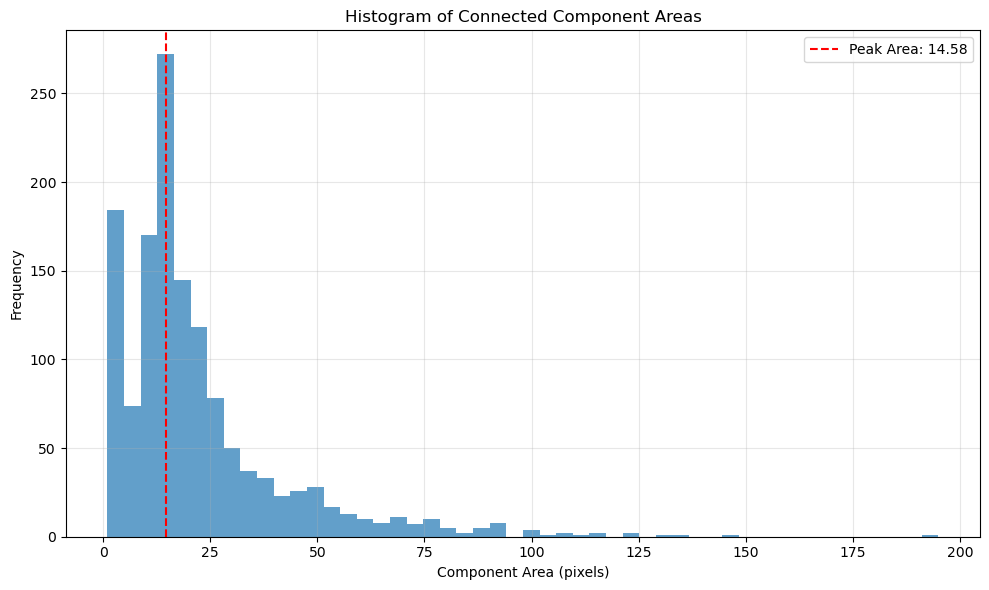

Total components: 1350
Filtered components (area between 3 and 43.74): 1037
Peak area from histogram: 14.58


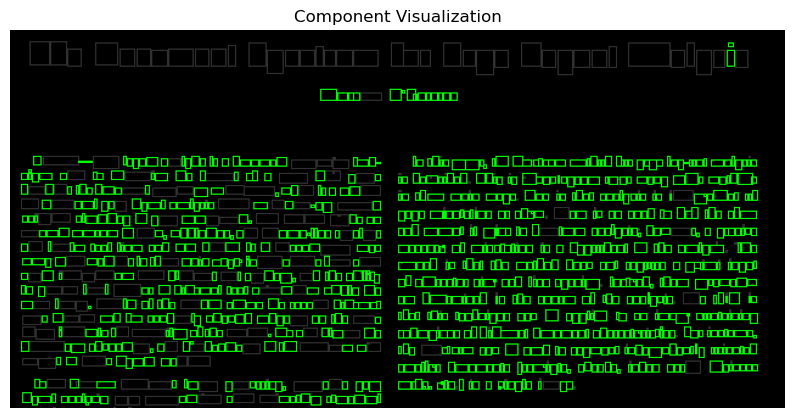

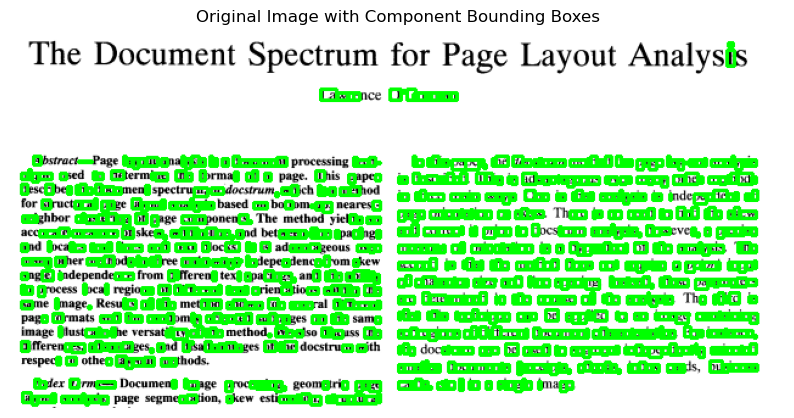

In [6]:
def find_and_filter_components(binary_image):
    """
    Find connected components, calculate their areas, plot a histogram,
    and filter based on the peak of the histogram.
    
    Args:
        binary_image (numpy.ndarray): Binary image (1 for foreground, 0 for background).
        
    Returns:
        list: List of filtered Component objects
        numpy.ndarray: Visualization image with components
    """
    # Make sure the binary image is in the format OpenCV expects (uint8, values 0 or 255)
    binary_for_cv = (binary_image * 255).astype(np.uint8)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_for_cv, connectivity=8)
    
    # Create Component objects for each connected component (skip the background label 0)
    components = []
    for i in range(1, num_labels):
        # Extract bounding box data
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        centroid = (centroids[i, 0], centroids[i, 1])
        
        # Instead of contour length, we'll use perimeter
        # Create a mask for this component
        component_mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_length = cv2.arcLength(contours[0], True) if contours else 0
        
        # Create Component object
        components.append(Component(bbox=(x, y, w, h), centroid=centroid, area=area, contour_length=contour_length))
    
    # Extract areas for histogram
    areas = [comp.area for comp in components]
    
    # Plot histogram of component areas
    plt.figure(figsize=(10, 6))
    hist, bin_edges = np.histogram(areas, bins=50)
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), alpha=0.7, align='edge')
    plt.xlabel('Component Area (pixels)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Connected Component Areas')
    
    # Find the peak of the histogram
    peak_bin_index = np.argmax(hist)
    peak_area = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2
    plt.axvline(peak_area, color='r', linestyle='--', label=f'Peak Area: {peak_area:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Set minimum and maximum area thresholds
    min_area = 3  # As per requirements
    max_area = 3 * peak_area  # 3 times the peak area
    
    # Filter components based on area criteria
    filtered_components = [comp for comp in components if min_area <= comp.area <= max_area]
    
    # Create a visualization image
    visualization = np.zeros((binary_image.shape[0], binary_image.shape[1], 3), dtype=np.uint8)
    
    # Draw original components in gray
    for comp in components:
        x, y, w, h = comp.bbox
        cv2.rectangle(visualization, (x, y), (x + w, y + h), (50, 50, 50), 1)
    
    # Draw filtered components in green with labels
    for i, comp in enumerate(filtered_components):
        x, y, w, h = comp.bbox
        cv2.rectangle(visualization, (x, y), (x + w, y + h), (0, 255, 0), 1)
        # cv2.putText(visualization, f'{i+1}', (int(comp.centroid[0]), int(comp.centroid[1])), 
        #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
    
    # Display basic stats
    print(f"Total components: {len(components)}")
    print(f"Filtered components (area between {min_area} and {max_area:.2f}): {len(filtered_components)}")
    print(f"Peak area from histogram: {peak_area:.2f}")
    
    return filtered_components, visualization

# Assuming you have already run the previous code to get the binary image
# Let's modify your code to incorporate the component analysis:

image = cv2.imread(image_path)

# Convert the image to grayscale first
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Otsu's thresholding on the grayscale image
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert if needed (assuming text is black)
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)
    
# Convert to binary format (0 and 1)
binary = (binary > 0).astype(np.uint8)

# Apply the Will filter (kFill) for noise reduction
filtered_binary = kfill(binary, k=kfill_threshold, max_iterations=max_iterations)

# Find and filter components
filtered_components, visualization = find_and_filter_components(filtered_binary)

# Display the visualization
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
plt.title('Component Visualization')
plt.axis('off')
plt.show()


filtered_image = np.zeros_like(filtered_binary)
for comp in filtered_components:
    x, y, w, h = comp.bbox
    # Extract the component from the original binary image and place it in the filtered image
    component_region = filtered_binary[y:y+h, x:x+w]
    filtered_image[y:y+h, x:x+w] = filtered_binary[y:y+h, x:x+w]

# Display the original image with bounding boxes around filtered components
plt.figure(figsize=(10, 8))
# Use a copy of the original image to avoid modifying it
original_with_boxes = image.copy()

# Draw bounding boxes for filtered components on the original image
for i, comp in enumerate(filtered_components):
    x, y, w, h = comp.bbox
    cv2.rectangle(original_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
    # cv2.putText(original_with_boxes, f'{i+1}', (int(comp.centroid[0]), int(comp.centroid[1])), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# Display the image with bounding boxes
plt.imshow(cv2.cvtColor(original_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Original Image with Component Bounding Boxes')
plt.axis('off')
plt.show()

# 2 Nearest-Neighbor Clustering and Docstrum Plot

In [7]:
def find_nearest_neighbors(components: List[Component], k = 5) -> List[List[Tuple[int, float, float]]]:
    """
    Find k nearest neighbors for each component
    
    Args:
        components: List of components
        
    Returns:
        List of lists containing (neighbor_idx, distance, angle) tuples for each component
    """
    if len(components) < k + 1:
        raise ValueError(f"Not enough components ({len(components)}) for k={k} nearest neighbors")
        
    # Extract centroids
    points = np.array([c.centroid for c in components])
    
    # Adjust k if necessary
    k = min(k + 1, len(components))
    print(f"Finding {k-1} nearest neighbors for each component")
    
    # Build KD-tree for efficient nearest neighbor search
    tree = KDTree(points)
    
    # Find k nearest neighbors (first one is the point itself)
    distances, indices = tree.query(points, k=k)
    
    neighbors_info = []
    for i, (component_neighbors, neighbor_distances) in enumerate(zip(indices, distances)):
        # Skip the first neighbor (point itself)
        neighbors = []
        for j, (neighbor_idx, dist) in enumerate(zip(component_neighbors[1:], neighbor_distances[1:]), 1):
            # Calculate angle between components
            dx = points[neighbor_idx][0] - points[i][0]
            dy = points[neighbor_idx][1] - points[i][1]
            angle = np.degrees(np.arctan2(dy, dx)) % 180
            
            neighbors.append((neighbor_idx, dist, angle))
        
        neighbors_info.append(neighbors)
        
    return neighbors_info

In [8]:
neighbors = find_nearest_neighbors(filtered_components, k=5)

Finding 5 nearest neighbors for each component


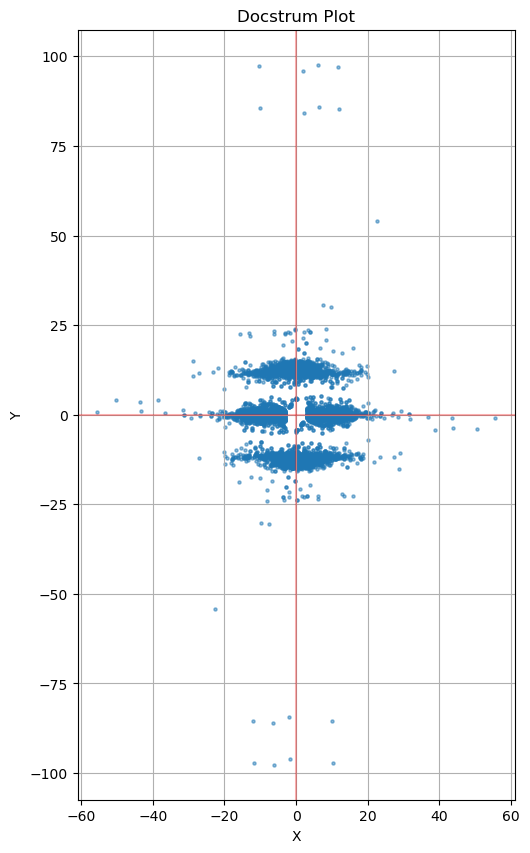

In [9]:
# 2.1 Docstrum Plot
def create_docstrum_plot(neighbors_info):
    """
    Create a docstrum plot from nearest-neighbor information
    
    Args:
        neighbors_info: List of lists containing (neighbor_idx, distance, angle) tuples
        
    Returns:
        matplotlib figure object with the docstrum plot
    """
    # Extract distances and angles from all neighbor pairs
    distances = []
    angles = []
    for component_neighbors in neighbors_info:
        for neighbor_idx, dist, angle in component_neighbors:
            distances.append(dist)
            angles.append(angle)
            # Add mirror point (rotate by 180 degrees) for symmetric visualization
            angles.append((angle + 180) % 360)
            distances.append(dist)
    
    # Convert to polar coordinates for plotting
    x_values = []
    y_values = []
    for dist, angle in zip(distances, angles):
        # Convert angle to radians
        angle_rad = np.radians(angle)
        # Calculate x and y coordinates
        x = dist * np.cos(angle_rad)
        y = dist * np.sin(angle_rad)
        x_values.append(x)
        y_values.append(y)
    
    # Create the docstrum plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(x_values, y_values, alpha=0.5, s=5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Docstrum Plot')
    ax.grid(True)
    ax.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='r', linestyle='-', alpha=0.3)
    ax.set_aspect('equal')
    
    return fig, ax, (distances, angles)

# Create the docstrum plot
docstrum_fig, docstrum_ax, (all_distances, all_angles) = create_docstrum_plot(neighbors)
plt.show()

In [10]:
# 2.2 Angle and Distance Histograms
def create_angle_histogram(angles, resolution=0.5, smoothing_window_percent=25):
    """
    Create a histogram of nearest-neighbor angles
    
    Args:
        angles: List of angles in degrees (0-360)
        resolution: Resolution in degrees per bin
        smoothing_window_percent: Smoothing window size as percentage of total range
        
    Returns:
        Tuple of (bin centers, histogram values, smoothed histogram values, peak angle)
    """
    # Restrict angles to [0, 180) range
    angles_180 = [angle % 180 for angle in angles]
    
    # Create histogram
    n_bins = int(180 / resolution)
    hist, bin_edges = np.histogram(angles_180, bins=n_bins, range=(0, 180))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate smoothing window size
    window_size = int(n_bins * smoothing_window_percent / 100)
    if window_size % 2 == 0:
        window_size += 1  # Ensure odd window size
    
    # Circular smoothing
    padded_hist = np.pad(hist, (window_size//2, window_size//2), mode='wrap')
    smoothed_hist = np.convolve(padded_hist, np.ones(window_size)/window_size, mode='valid')
    
    # Find peak angle
    peak_idx = np.argmax(smoothed_hist)
    peak_angle = bin_centers[peak_idx]
    
    return bin_centers, hist, smoothed_hist, peak_angle


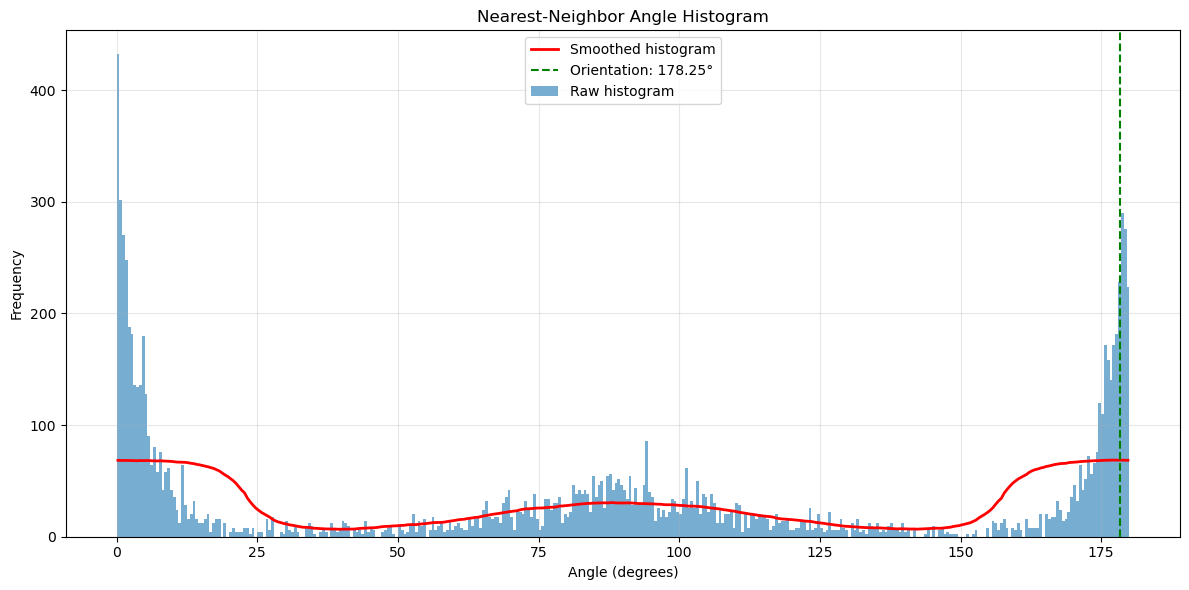

Initial text orientation estimate: 178.25 degrees


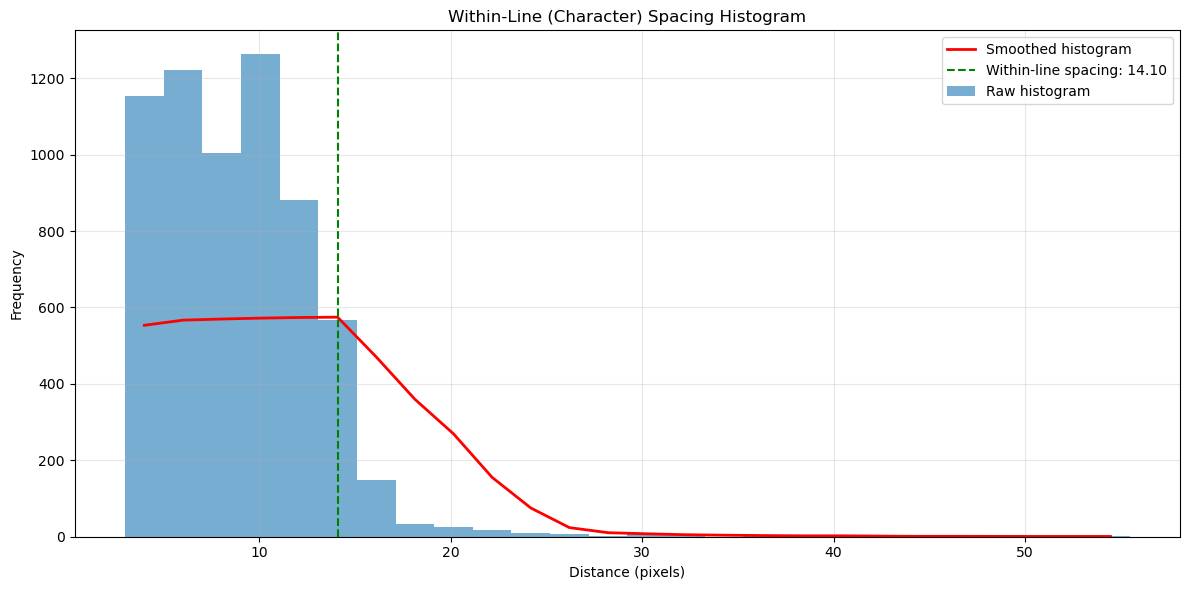

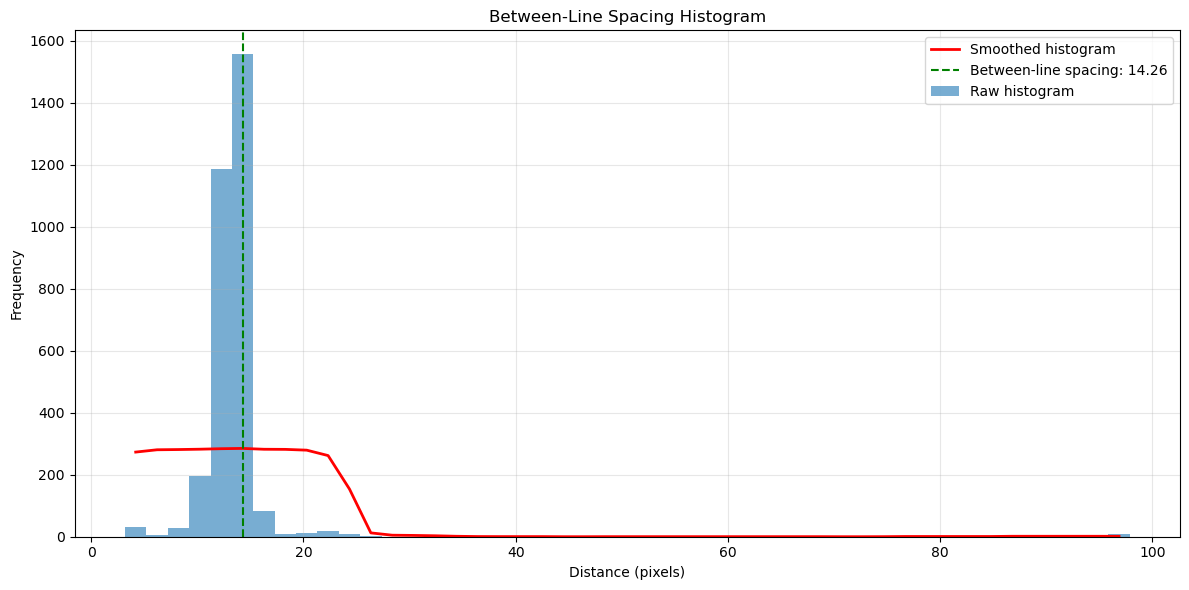

Character spacing: 14.10 pixels
Line spacing: 14.26 pixels


In [11]:
def create_distance_histogram(distances, angles, reference_angle, angle_tolerance=30, 
                             resolution=2, tolerance_pixels=2, rs = 2):
    """
    Create histogram of distances for angles within tolerance of reference angle
    
    Args:
        distances: List of distances
        angles: List of angles (same length as distances)
        reference_angle: Reference angle in degrees
        angle_tolerance: Tolerance around reference angle in degrees
        resolution: Resolution in pixels per bin
        tolerance_pixels: Tolerance for peak detection in pixels
        
    Returns:
        Tuple of (bin centers, histogram values, smoothed histogram values, peak distance)
    """
    # Filter distances by angle tolerance
    angles_180 = [angle % 180 for angle in angles]
    filtered_distances = []
    
    for dist, angle in zip(distances, angles_180):
        angle_diff = min((angle - reference_angle) % 180, (reference_angle - angle) % 180)
        if angle_diff <= angle_tolerance:
            filtered_distances.append(dist)
    
    if not filtered_distances:
        return None, None, None, None
    
    # Create histogram
    max_dist = max(filtered_distances)
    min_dist = min(filtered_distances)
    n_bins = int((max_dist - min_dist) / resolution) 
    
    hist, bin_edges = np.histogram(filtered_distances, bins=n_bins, range=(min_dist, max_dist))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate smoothing window size
    window_size = rs * (2 * tolerance_pixels + 1) + 1 # todo : is this correct ?
    
    # Smoothing
    padded_hist = np.pad(hist, (window_size//2, window_size//2), mode='constant')
    smoothed_hist = np.convolve(padded_hist, np.ones(window_size)/window_size, mode='valid')
    
    # Find peak distance
    peak_idx = np.argmax(smoothed_hist)
    peak_distance = bin_centers[peak_idx]
    
    return bin_centers, hist, smoothed_hist, peak_distance

# Generate angle histogram and find orientation
angle_bins, angle_hist, angle_smooth, orientation = create_angle_histogram(all_angles)

plt.figure(figsize=(12, 6))
plt.bar(angle_bins, angle_hist, width=angle_bins[1]-angle_bins[0], alpha=0.6, label='Raw histogram')
plt.plot(angle_bins, angle_smooth, 'r-', linewidth=2, label='Smoothed histogram')
plt.axvline(x=orientation, color='g', linestyle='--', 
            label=f'Orientation: {orientation:.2f}°')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.title('Nearest-Neighbor Angle Histogram')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial text orientation estimate: {orientation:.2f} degrees")

# Find within-line spacing (character spacing)
within_line_bins, within_line_hist, within_line_smooth, within_line_spacing = create_distance_histogram(
    all_distances, all_angles, orientation, angle_tolerance=30
)

plt.figure(figsize=(12, 6))
plt.bar(within_line_bins, within_line_hist, width=within_line_bins[1]-within_line_bins[0], 
        alpha=0.6, label='Raw histogram')
plt.plot(within_line_bins, within_line_smooth, 'r-', linewidth=2, label='Smoothed histogram')
plt.axvline(x=within_line_spacing, color='g', linestyle='--', 
            label=f'Within-line spacing: {within_line_spacing:.2f}')
plt.xlabel('Distance (pixels)')
plt.ylabel('Frequency')
plt.title('Within-Line (Character) Spacing Histogram')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find between-line spacing
perpendicular_angle = (orientation + 90) % 180
between_line_bins, between_line_hist, between_line_smooth, between_line_spacing = create_distance_histogram(
    all_distances, all_angles, perpendicular_angle, angle_tolerance=30
)

plt.figure(figsize=(12, 6))
plt.bar(between_line_bins, between_line_hist, width=between_line_bins[1]-between_line_bins[0], 
        alpha=0.6, label='Raw histogram')
plt.plot(between_line_bins, between_line_smooth, 'r-', linewidth=2, label='Smoothed histogram')
plt.axvline(x=between_line_spacing, color='g', linestyle='--', 
            label=f'Between-line spacing: {between_line_spacing:.2f}')
plt.xlabel('Distance (pixels)')
plt.ylabel('Frequency')
plt.title('Between-Line Spacing Histogram')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Character spacing: {within_line_spacing:.2f} pixels")
print(f"Line spacing: {between_line_spacing:.2f} pixels")


# 3. Determination of text lines and accurate orientation measurement

In [12]:
# 2.3 Text Line Finding via Transitive Closure and Regression

def find_text_lines(components, neighbors_info, orientation, within_line_spacing, angle_tolerance=30):
    """
    Find text lines using transitive closure on nearest-neighbor pairs
    
    Args:
        components: List of Component objects
        neighbors_info: List of lists containing (neighbor_idx, distance, angle) tuples
        orientation: Text orientation in degrees
        within_line_spacing: Within-line spacing threshold
        angle_tolerance: Tolerance around orientation angle
        
    Returns:
        List of text line groups, each containing indices of components in the line
    """
    # Create graph for connected components
    n_components = len(components)
    graph = [[] for _ in range(n_components)]
    
    # Define the maximum distance threshold 
    distance_threshold = min(3 * within_line_spacing, (np.sqrt(2) * between_line_spacing))
    
    # Add edges to the graph for components that are likely on the same line
    for i, component_neighbors in enumerate(neighbors_info):
        for neighbor_idx, dist, angle in component_neighbors:
            # Check if this neighbor is along the text orientation direction
            angle_diff = min((angle - orientation) % 180, (orientation - angle) % 180)
            if angle_diff <= angle_tolerance and dist <= distance_threshold:
                graph[i].append(neighbor_idx)
                graph[neighbor_idx].append(i)
    
    # Ensure no duplicate edges
    for i in range(n_components):
        graph[i] = list(set(graph[i]))
    
    # Perform transitive closure using breadth-first search to find connected components
    visited = [False] * n_components
    text_lines = []
    
    for i in range(n_components):
        if not visited[i]:
            # Start a new text line
            line = []
            queue = [i]
            visited[i] = True
            
            while queue:
                node = queue.pop(0)
                line.append(node)
                
                for neighbor in graph[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            
            text_lines.append(line)
    
    return text_lines

In [13]:
def fit_lines_to_text_groups(components, text_lines):
    """
    Fit regression lines to each text line group
    
    Args:
        components: List of Component objects
        text_lines: List of lists, each containing indices of components in a line
        
    Returns:
        List of (slope, intercept, x_min, x_max) for each text line
    """
    fitted_lines = []
    
    for line_indices in text_lines:
        if len(line_indices) < 2:
            continue  # Need at least two points for a line
        
        # Extract centroids for this line
        x_points = [components[idx].centroid[0] for idx in line_indices]
        y_points = [components[idx].centroid[1] for idx in line_indices]
        
        # Skip if all x values are the same (vertical line)
        if len(set(x_points)) <= 1:
            continue
        
        # Fit line using least squares regression
        A = np.vstack([x_points, np.ones(len(x_points))]).T
        slope, intercept = np.linalg.lstsq(A, y_points, rcond=None)[0]
        
        # Store line parameters
        x_min, x_max = min(x_points), max(x_points)
        fitted_lines.append((slope, intercept, x_min, x_max))
    
    return fitted_lines

In [14]:
def calculate_refined_orientation(fitted_lines):
    """
    Calculate refined orientation from fitted lines
    
    Args:
        fitted_lines: List of (slope, intercept, x_min, x_max) for each text line
        
    Returns:
        Refined orientation in degrees
    """
    # Weight lines by their length
    slopes = []
    weights = []
    
    for slope, _, x_min, x_max in fitted_lines:
        # Skip near-vertical lines
        if abs(slope) > 10:
            continue
            
        line_length = x_max - x_min
        slopes.append(slope)
        weights.append(line_length)
    
    if not slopes:
        return None
    
    # Calculate weighted average of slopes
    weighted_slope = np.average(slopes, weights=weights)
    
    # Convert slope to angle in degrees
    refined_orientation = np.degrees(np.arctan(weighted_slope))
    
    return refined_orientation

# Find text lines
text_lines = find_text_lines(filtered_components, neighbors, orientation, within_line_spacing)

# Filter out very small lines (noise)
text_lines = [line for line in text_lines if len(line) >= 3]

print(f"Found {len(text_lines)} text lines")

# Fit regression lines to text line groups
fitted_lines = fit_lines_to_text_groups(filtered_components, text_lines)

# Calculate refined orientation
refined_orientation = calculate_refined_orientation(fitted_lines)
print(f"Refined orientation estimate: {refined_orientation:.2f} degrees")


Found 76 text lines
Refined orientation estimate: 0.10 degrees


/tmp/ipykernel_143606/2370346723.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(text_lines))


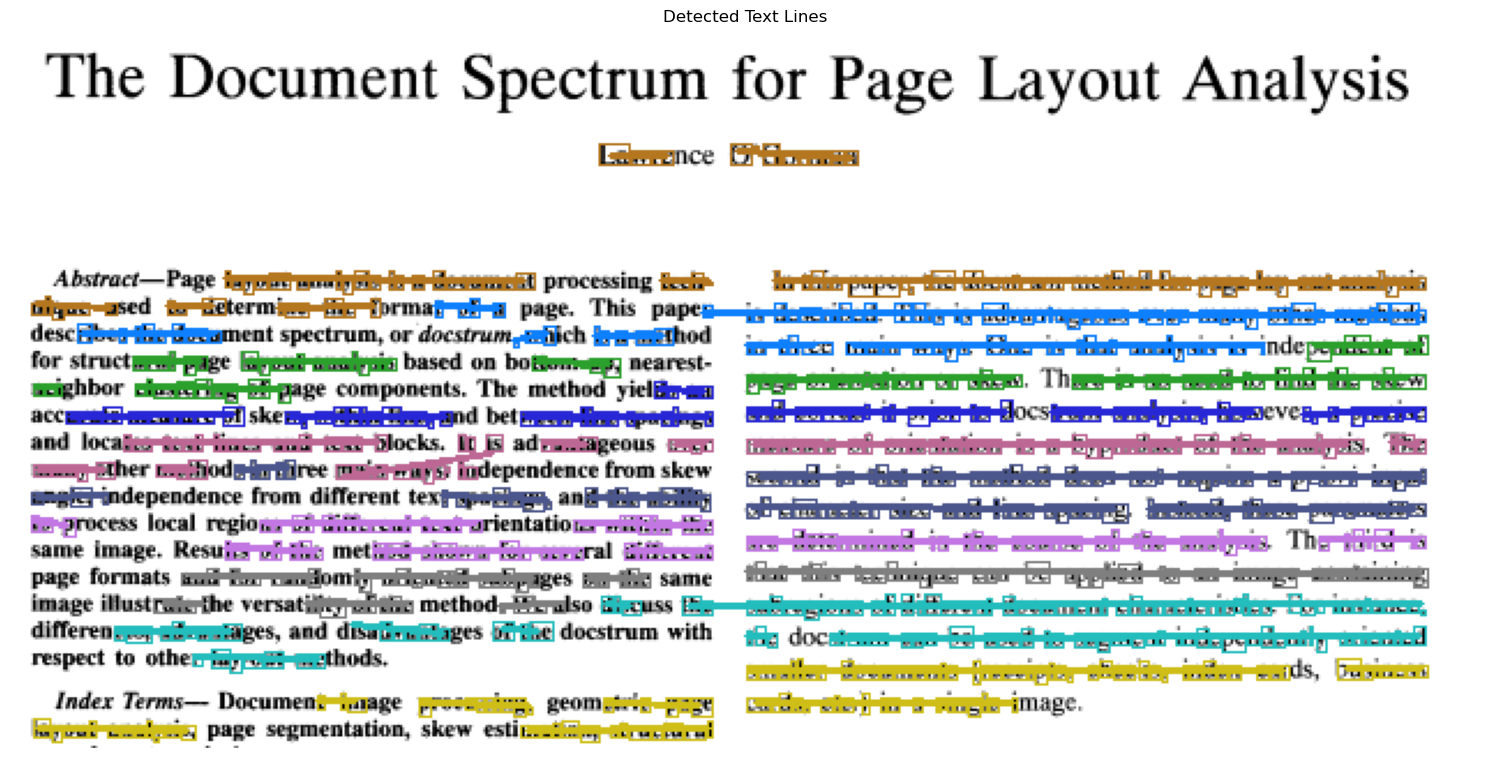

In [15]:
# 2.4 Visualization of Text Lines

def visualize_text_lines(image, components, text_lines, fitted_lines):
    """
    Visualize detected text lines on the image
    
    Args:
        image: Original image
        components: List of Component objects
        text_lines: List of lists, each containing indices of components in a line
        fitted_lines: List of (slope, intercept, x_min, x_max) for each text line
        
    Returns:
        Visualization image
    """
    # Create a visualization image
    visualization = image.copy()
    
    # Assign different colors to different text lines
    cmap = plt.cm.get_cmap('tab10', len(text_lines))
    colors = [(int(c[0]*255), int(c[1]*255), int(c[2]*255)) for c in cmap.colors]
    
    # Draw boxes for each component based on text line
    for i, line_indices in enumerate(text_lines):
        color = colors[i % len(colors)]
        
        for idx in line_indices:
            x, y, w, h = components[idx].bbox
            cv2.rectangle(visualization, (x, y), (x+w, y+h), color, 1)
    
    # Draw fitted lines
    for i, (slope, intercept, x_min, x_max) in enumerate(fitted_lines):
        color = colors[i % len(colors)]
        
        y_min = int(slope * x_min + intercept)
        y_max = int(slope * x_max + intercept)
        
        cv2.line(visualization, (int(x_min), y_min), (int(x_max), y_max), color, 2)
    
    return visualization

# Visualize the text lines
lines_visualization = visualize_text_lines(image, filtered_components, text_lines, fitted_lines)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(lines_visualization, cv2.COLOR_BGR2RGB))
plt.title('Detected Text Lines')
plt.axis('off')
plt.tight_layout()
plt.show()


# 4. Structural Block Determination

In [16]:
def check_parallelness(slope1, slope2, tolerance_degrees=30):
    """
    Check if two lines are approximately parallel within the given tolerance
    
    Args:
        slope1: Slope of the first line
        slope2: Slope of the second line
        tolerance_degrees: Maximum angular difference allowed (in degrees)
        
    Returns:
        Boolean indicating if the lines are parallel within tolerance
    """
    # todo : small changes are they okay ? exemple slope:
    angle1 = np.degrees(np.arctan(slope1))
    angle2 = np.degrees(np.arctan(slope2))
    diff = abs(angle1 - angle2)
    # Account for angles that wrap around (consider the smaller of the two possible differences)
    diff = min(diff, 180 - diff)
    return diff <= tolerance_degrees

In [ ]:
def calculate_A_coordinates(line1, line2):

    slope1, intercept1, x_min1, x_max1 = line1
    slope2, intercept2, x_min2, x_max2 = line2

    y_min1 = slope1 * x_min1 + intercept1
    y_max1 = slope1 * x_max1 + intercept1

    y_min2 = slope2 * x_min2 + intercept2
    y_max2 = slope2 * x_max2 + intercept2


    delta_x1 = x_max1 - x_min1
    delta_y1 = y_max1 - y_min1

    delta_x2 = x_max2 - x_min2
    delta_y2 = y_max2 - y_min2

    if delta_x1 != 0:
        A = x_min1 * delta_x1 * delta_x2
        B = x_min2 * delta_y1 * delta_y2
        C = delta_x2 * delta_y1 * (y_min1 - y_min2)
        D = delta_y1 * delta_y2 + delta_x1 * delta_x2
        x_A2 = (A + B + C) / D
        y_A2 = slope2 * x_A2 + intercept2

        E = x_max1 * delta_x1 * delta_x2
        F = x_max2 * delta_y1 * delta_y2
        G = delta_x2 * delta_y1 * (y_max1 - y_max2)
        x_B2 = (E + F + G) / D
        y_B2 = slope2 * x_B2 + intercept2

    else:
        A = y_min1 * delta_y1 * delta_y2
        B = y_min2 * delta_x1 * delta_x2
        C = delta_y2 * delta_x1 * (x_min1 - x_min2)
        D = delta_x1 * delta_x2 + delta_y1 * delta_y2
        y_A2 = (A + B + C) / D
        x_A2 = (y_A2 - y_min2) * (delta_x2 / delta_y2) + x_min2

        E = y_max1 * delta_y1 * delta_y2
        F = y_max2 * delta_x1 * delta_x2
        G = delta_y2 * delta_x1 * (x_max1 - x_max2)
        y_B2 = (E + F + G) / D
        x_B2 = (y_B2 - y_max2) * (delta_x2 / delta_y2) + x_max2

    return x_A2, y_A2, x_B2, y_B2

In [ ]:
def calculate_perpendicular_distance(line1, line2):
    """
    Calculate the perpendicular distance between two non-overlapping text lines
    
    Args:
        line1: Tuple of (slope, intercept, x_min, x_max) for the first line
        line2: Tuple of (slope, intercept, x_min, x_max) for the second line
        
    Returns:
        Perpendicular distance between the two lines (minimum distance between endpoints)
    """
    slope1, intercept1, x_min1, x_max1 = line1
    slope2, intercept2, x_min2, x_max2 = line2

    y_min1 = slope1 * x_min1 + intercept1
    y_max1 = slope1 * x_max1 + intercept1

    y_min2 = slope2 * x_min2 + intercept2
    y_max2 = slope2 * x_max2 + intercept2



    x_A2, y_A2, x_B2, y_B2 = calculate_A_coordinates(line1, line2)

    list_coord = [(x_min2, y_min2), (x_max2, y_max2), (x_A2, y_A2), (x_B2, y_B2)]
    if (x_max2 - x_min2) != 0:
        list_coord.sort(key=lambda x: x[0])
    else:
        list_coord.sort(key=lambda x: x[1])

    (x_C2, y_C2), (x_D2, y_D2) = list_coord[1], list_coord[2]

    x_M, y_M = (x_C2 + x_D2) / 2, (y_C2 + y_D2) / 2

    delta_x1 = x_max1 - x_min1
    delta_y1 = y_max1 - y_min1

    if delta_x1 == 0:
        return np.abs(x_M - x_min1)
    elif delta_y1 == 0:
        return np.abs(y_M - y_min1)
    else:
        num = (x_M-x_min1) - (y_M-y_min1)*delta_x1/delta_y1
        den = np.sqrt(1 + (delta_x1/delta_y1)**2)
        return np.abs(num / den)


In [ ]:
def check_overlap(line1, line2):
    """
    Check if two text lines overlap horizontally
    
    Args:
        line1: Tuple of (slope, intercept, x_min, x_max) for the first line
        line2: Tuple of (slope, intercept, x_min, x_max) for the second line
        
    Returns:
        Boolean indicating if the lines overlap and the overlap measure
    """
    slope1, intercept1, x_min1, x_max1 = line1
    slope2, intercept2, x_min2, x_max2 = line2

    y_min1 = slope1 * x_min1 + intercept1
    y_max1 = slope1 * x_max1 + intercept1

    y_min2 = slope2 * x_min2 + intercept2
    y_max2 = slope2 * x_max2 + intercept2



    x_A2, y_A2, x_B2, y_B2 = calculate_A_coordinates(line1, line2)

    list_coord = [(x_min2, y_min2), (x_max2, y_max2), (x_A2, y_A2), (x_B2, y_B2)]
    if (x_max2 - x_min2) != 0:
        list_coord.sort(key=lambda x: x[0])
    else:
        list_coord.sort(key=lambda x: x[1])

    (x_C2, y_C2), (x_D2, y_D2) = list_coord[1], list_coord[2]
    
    p2 = np.sqrt((y_D2 - y_C2)**2 + (x_D2 - x_C2)**2)
    

    #l2 lenght of the line 2

    l2 = np.sqrt((y_max2 - y_min2)**2 + (x_max2 - x_min2)**2)
    

    # These middle points are contained within both segments if they are overlapped, or they define a segment between them if they are not overlapped.
    x_min2, x_max2 = min(x_min2, x_max2), max(x_min2, x_max2)
    x_A2, x_B2 = min(x_A2, x_B2), max(x_A2, x_B2)
    if (x_A2 >= x_min2 and x_A2 <= x_max2) or (x_B2 >= x_min2 and x_B2 <= x_max2) or (x_min2 >= x_A2 and x_min2<= x_B2) or (x_max2 >= x_A2 and x_max2<= x_B2) :
        overlap = True
    else :
        overlap = False

    if overlap : 
        overlap_measure = p2 / l2
    
    else :
        overlap_measure = -1 * p2 / l2  


    return overlap, overlap_measure

In [ ]:
def calculate_parallel_distance(line1, line2):
    """
    Calculate the parallel distance between two non-overlapping text lines
    
    Args:
        line1: Tuple of (slope, intercept, x_min, x_max) for the first line
        line2: Tuple of (slope, intercept, x_min, x_max) for the second line
        
    Returns:
        Parallel distance between the two lines (minimum distance between endpoints)
    """
    slope1, intercept1, x_min1, x_max1 = line1
    slope2, intercept2, x_min2, x_max2 = line2

    y_min1 = slope1 * x_min1 + intercept1
    y_max1 = slope1 * x_max1 + intercept1

    y_min2 = slope2 * x_min2 + intercept2
    y_max2 = slope2 * x_max2 + intercept2



    x_A2, y_A2, x_B2, y_B2 = calculate_A_coordinates(line1, line2)

    list_coord = [(x_min2, y_min2), (x_max2, y_max2), (x_A2, y_A2), (x_B2, y_B2)]
    if (x_max2 - x_min2) != 0:
        list_coord.sort(key=lambda x: x[0])
    else:
        list_coord.sort(key=lambda x: x[1])

    (x_C2, y_C2), (x_D2, y_D2) = list_coord[1], list_coord[2]
    
    p2 = np.sqrt((y_D2 - y_C2)**2 + (x_D2 - x_C2)**2)    

    # These middle points are contained within both segments if they are overlapped, or they define a segment between them if they are not overlapped.
    x_min2, x_max2 = min(x_min2, x_max2), max(x_min2, x_max2)
    x_A2, x_B2 = min(x_A2, x_B2), max(x_A2, x_B2)
    if (x_A2 >= x_min2 and x_A2 <= x_max2) or (x_B2 >= x_min2 and x_B2 <= x_max2) or (x_min2 >= x_A2 and x_min2<= x_B2) or (x_max2 >= x_A2 and x_max2<= x_B2) :
        overlap = True
    else :
        overlap = False

    if overlap : 
        parallel_distance = p2
    
    else :
        parallel_distance = -1 * p2

    return parallel_distance

In [20]:
def find_text_blocks(filtered_components, text_lines, fitted_lines, within_line_spacing, between_line_spacing, orientation):
    """
    Find text blocks by grouping text lines based on geometric and spatial relationships
    
    Args:
        filtered_components: List of Component objects
        text_lines: List of lists, each containing indices of components in a line
        fitted_lines: List of (slope, intercept, x_min, x_max) for each text line
        within_line_spacing: Average within-line spacing
        between_line_spacing: Average between-line spacing
        orientation: Refined text orientation in degrees
        
    Returns:
        List of text blocks, each containing lists of text line indices
        List of text blocks, each containing lists of component indices
    """
    # Set threshold parameters based on average spacings
    max_perpendicular_dist = 1.3 * between_line_spacing  # Max distance between lines in same block
    max_parallel_dist = 1.5 * within_line_spacing  # Max distance between ends of lines in same block
    parallelness_tolerance = 30  # Degrees tolerance for line slopes
    
    # Create a list to track block assignments for each text line
    n_lines = len(text_lines)
    line_to_block = [-1] * n_lines  # -1 means not assigned to any block yet
    blocks = []
    
    # Calculate pairwise line relationships
    for i in range(n_lines):
        
        # Get parameters of line i
        if i >= len(fitted_lines):
            continue
        line_i = fitted_lines[i]
        
        for j in range(i+1, n_lines):
            if len(text_lines[j]) < 2:
                continue
                
            # Get parameters of line j
            if j >= len(fitted_lines):
                continue
            line_j = fitted_lines[j]
            
            # Check all four criteria:
            # 1. Parallelness
            if not check_parallelness(line_i[0], line_j[0], parallelness_tolerance):
                continue
            
            # 2. Perpendicular proximity
            perp_dist = calculate_perpendicular_distance(line_i, line_j)
            if perp_dist > max_perpendicular_dist:
                continue
            
            # 3. Overlap check
            has_overlap, overlap_measure = check_overlap(line_i, line_j)
            
            # 4. Parallel proximity (only check if no overlap)
            if not has_overlap:
                parallel_dist = calculate_parallel_distance(line_i, line_j)
                if parallel_dist > max_parallel_dist:
                    continue
            
            # If we reach here, the lines should be in the same block
            # Perform block assignment/merging
            if line_to_block[i] == -1 and line_to_block[j] == -1:
                # Both lines not assigned, create new block
                block_id = len(blocks)
                blocks.append([i, j])
                line_to_block[i] = block_id
                line_to_block[j] = block_id
            elif line_to_block[i] == -1:
                # Line i not assigned, add to j's block
                block_id = line_to_block[j]
                blocks[block_id].append(i)
                line_to_block[i] = block_id
            elif line_to_block[j] == -1:
                # Line j not assigned, add to i's block
                block_id = line_to_block[i]
                blocks[block_id].append(j)
                line_to_block[j] = block_id
            elif line_to_block[i] != line_to_block[j]:
                # Both assigned to different blocks, merge blocks
                block_id_i = line_to_block[i]
                block_id_j = line_to_block[j]
                # Get all lines from block j
                lines_to_move = blocks[block_id_j].copy()
                # Add them to block i
                blocks[block_id_i].extend(lines_to_move)
                # Update block assignments
                for line_idx in lines_to_move:
                    line_to_block[line_idx] = block_id_i
                # Set block j as empty (we'll filter these out later)
                blocks[block_id_j] = []
    
    # Handle unassigned lines (create singleton blocks)
    for i in range(n_lines):
        if line_to_block[i] == -1 and len(text_lines[i]) >= 2:
            block_id = len(blocks)
            blocks.append([i])
            line_to_block[i] = block_id
    
    # Filter out empty blocks
    blocks = [block for block in blocks if block]
    
    # Convert text line indices to the actual component indices
    text_blocks = []
    for block in blocks:
        components_in_block = []
        for line_idx in block:
            components_in_block.extend(text_lines[line_idx])
        text_blocks.append(components_in_block)
    
    return blocks, text_blocks

/tmp/ipykernel_143606/1759608271.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(text_blocks))


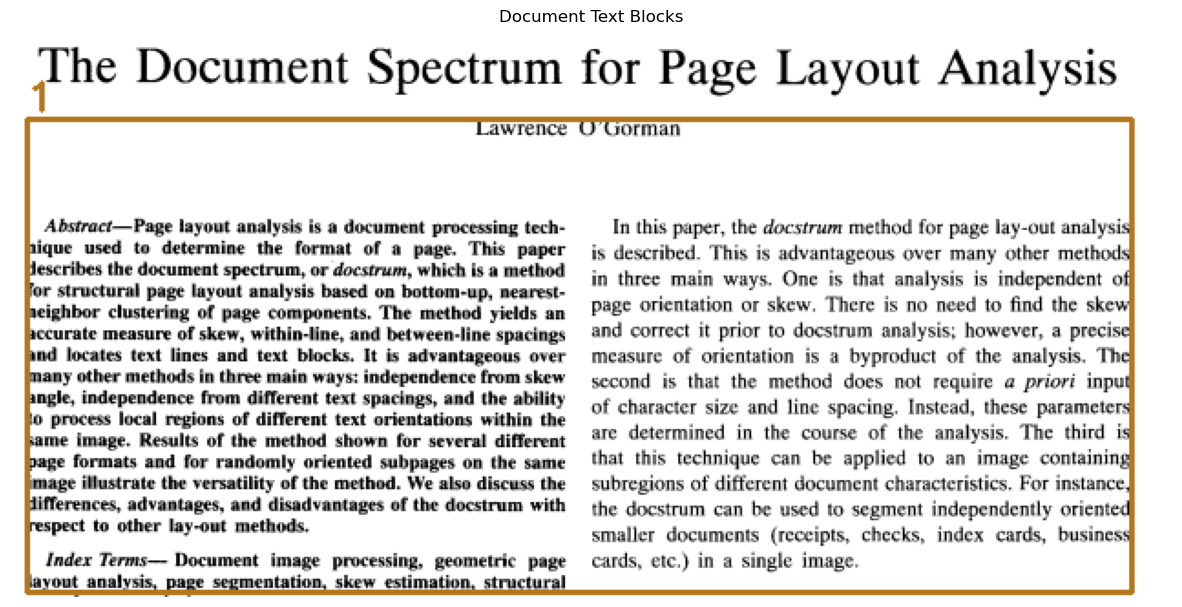

In [21]:
def visualize_text_blocks(image, filtered_components, text_blocks):
    """
    Visualize text blocks on the image
    
    Args:
        image: Original image
        filtered_components: List of Component objects
        text_blocks: List of lists, each containing indices of components in a block
        
    Returns:
        Visualization image with text blocks outlined
    """
    # Create a copy of the image for visualization
    visualization = image.copy()
    
    # Assign different colors to different blocks
    cmap = plt.cm.get_cmap('tab20', len(text_blocks))
    colors = [(int(c[0]*255), int(c[1]*255), int(c[2]*255)) for c in cmap.colors]
    
    # Draw blocks
    for i, block_components in enumerate(text_blocks):
        color = colors[i % len(colors)]
        
        # Get bounding box for the entire block
        if not block_components:
            continue
            
        # Initialize with the first component
        comp_idx = block_components[0]
        if comp_idx >= len(filtered_components):
            continue
            
        x, y, w, h = filtered_components[comp_idx].bbox
        min_x, min_y = x, y
        max_x, max_y = x + w, y + h
        
        # Expand bounding box to include all components in the block
        for comp_idx in block_components[1:]:
            if comp_idx >= len(filtered_components):
                continue
            x, y, w, h = filtered_components[comp_idx].bbox
            min_x = min(min_x, x)
            min_y = min(min_y, y)
            max_x = max(max_x, x + w)
            max_y = max(max_y, y + h)
        
        # Draw the block bounding box
        cv2.rectangle(visualization, (min_x, min_y), (max_x, max_y), color, 2)
        
        # Add a block label
        cv2.putText(visualization, f'{i+1}', (min_x, min_y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    
    return visualization

# Example usage:
blocks, component_blocks = find_text_blocks(filtered_components, text_lines, fitted_lines, within_line_spacing, between_line_spacing, refined_orientation)
blocks_visualization = visualize_text_blocks(image, filtered_components, component_blocks)
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(blocks_visualization, cv2.COLOR_BGR2RGB))
plt.title('Document Text Blocks')
plt.axis('off')
plt.show()